In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('https://raw.githubusercontent.com/010Ankushsharma/datasets/refs/heads/main/water_contamination_dataset.csv')

In [6]:
print (df.head())

      village        date    pH  turbidity  dissolved_oxygen  nitrates  \
0    Ambegaon  2023-01-01  6.73       2.87              8.85      8.59   
1    Laxmipur  2023-01-01  8.26       2.16              8.07     11.26   
2  Bhavanipur  2023-01-01  6.25       1.00              9.82      9.64   
3     Morwada  2023-01-01  6.07       2.77              8.37     11.16   
4    Nandgaon  2023-01-01  6.68       2.38              9.30     11.52   

   coliform  rainfall  temperature  diarrhea_cases  growth_rate  \
0      47.4      19.7         25.1               4        0.314   
1      66.4      25.9         20.4               8        0.346   
2      16.8       5.4         22.2               2        0.141   
3      43.7       7.6         22.0               3        0.194   
4      52.7       1.4         22.8               6        0.303   

   contamination_score  
0                19.45  
1                21.18  
2                 8.66  
3                19.58  
4                14.54  


In [7]:
print(df.shape)

(2200, 12)


In [8]:
print(df.info)

<bound method DataFrame.info of          village        date    pH  turbidity  dissolved_oxygen  nitrates  \
0       Ambegaon  2023-01-01  6.73       2.87              8.85      8.59   
1       Laxmipur  2023-01-01  8.26       2.16              8.07     11.26   
2     Bhavanipur  2023-01-01  6.25       1.00              9.82      9.64   
3        Morwada  2023-01-01  6.07       2.77              8.37     11.16   
4       Nandgaon  2023-01-01  6.68       2.38              9.30     11.52   
...          ...         ...   ...        ...               ...       ...   
2195    Radhapur  2023-12-30  6.37       1.00              9.64     12.44   
2196    Sonegaon  2023-12-31  6.90       1.86              9.62      9.10   
2197  Bhavanipur  2023-12-31  7.22       1.00              9.38     17.39   
2198  Bhavanipur  2023-12-31  6.89       1.28              9.39      8.49   
2199    Chikhali  2023-12-31  5.51      10.00              4.26      9.91   

      coliform  rainfall  temperature  diar

In [9]:
print(df.describe)

<bound method NDFrame.describe of          village        date    pH  turbidity  dissolved_oxygen  nitrates  \
0       Ambegaon  2023-01-01  6.73       2.87              8.85      8.59   
1       Laxmipur  2023-01-01  8.26       2.16              8.07     11.26   
2     Bhavanipur  2023-01-01  6.25       1.00              9.82      9.64   
3        Morwada  2023-01-01  6.07       2.77              8.37     11.16   
4       Nandgaon  2023-01-01  6.68       2.38              9.30     11.52   
...          ...         ...   ...        ...               ...       ...   
2195    Radhapur  2023-12-30  6.37       1.00              9.64     12.44   
2196    Sonegaon  2023-12-31  6.90       1.86              9.62      9.10   
2197  Bhavanipur  2023-12-31  7.22       1.00              9.38     17.39   
2198  Bhavanipur  2023-12-31  6.89       1.28              9.39      8.49   
2199    Chikhali  2023-12-31  5.51      10.00              4.26      9.91   

      coliform  rainfall  temperature  di

In [10]:
print(df.isnull().sum())

village                0
date                   0
pH                     0
turbidity              0
dissolved_oxygen       0
nitrates               0
coliform               0
rainfall               0
temperature            0
diarrhea_cases         0
growth_rate            0
contamination_score    0
dtype: int64


In [11]:
df.nunique()

,0
village,35
date,365
pH,292
turbidity,555
dissolved_oxygen,450
nitrates,1428
coliform,1153
rainfall,765
temperature,173
diarrhea_cases,22


In [13]:
### convert date

df['date']=pd.to_datetime(df['date'])
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month


UNIVARIATE ANALYSIS (Each column individually)

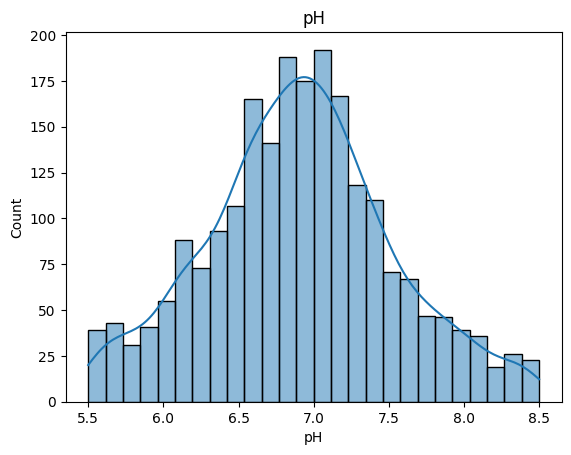

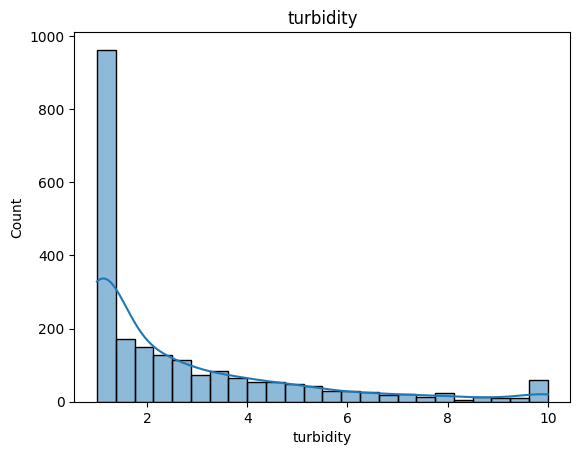

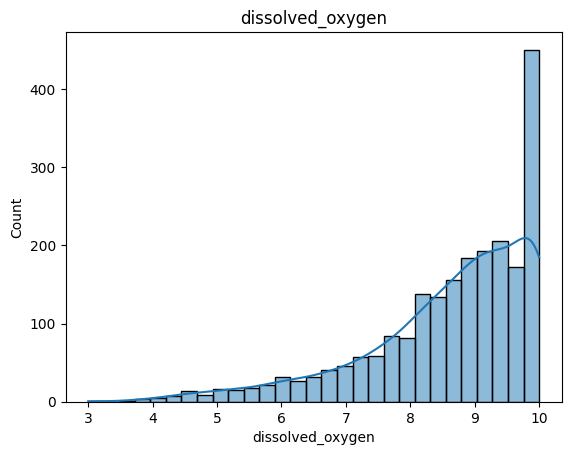

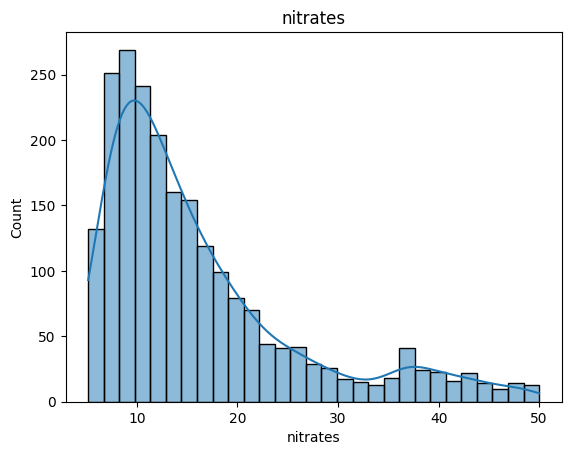

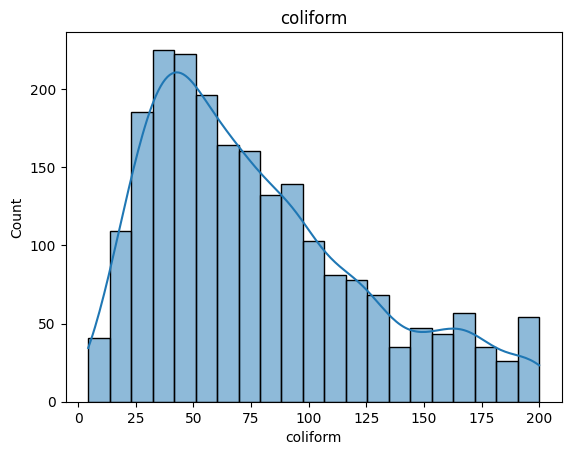

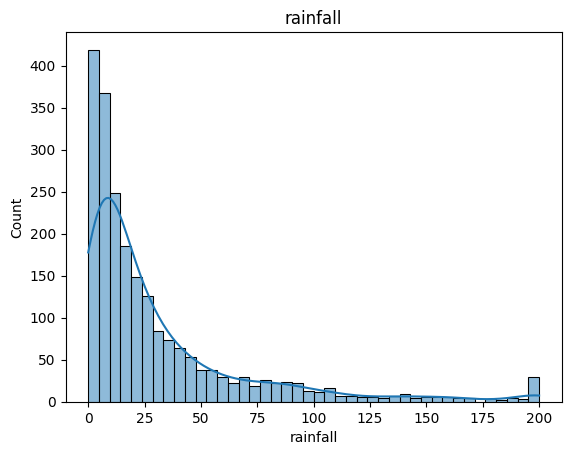

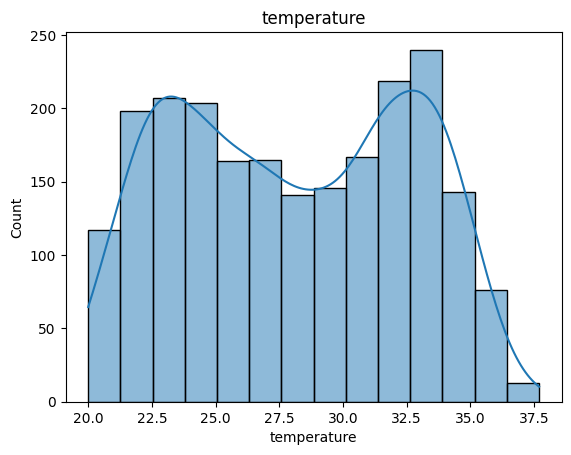

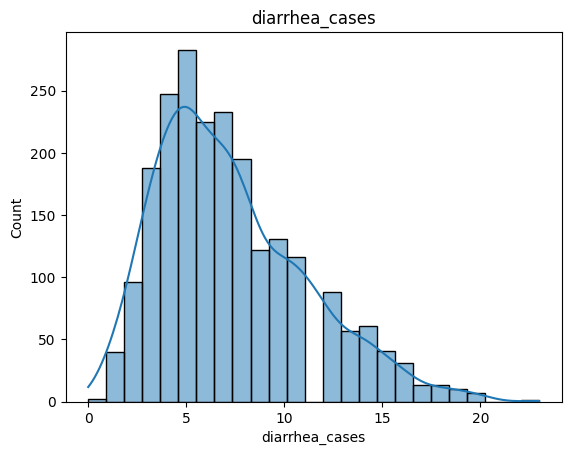

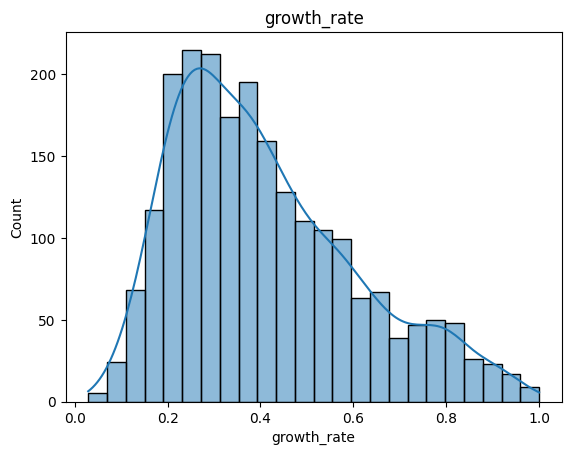

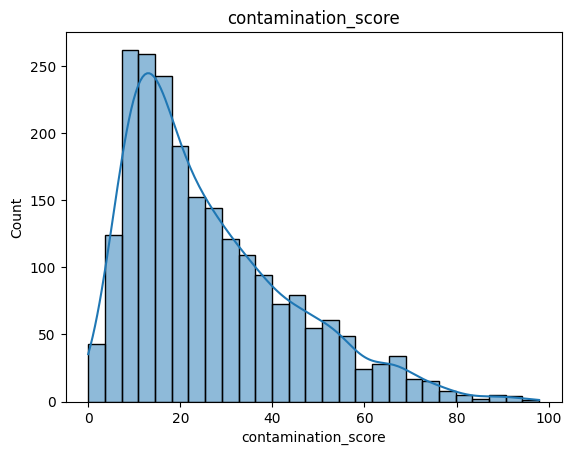

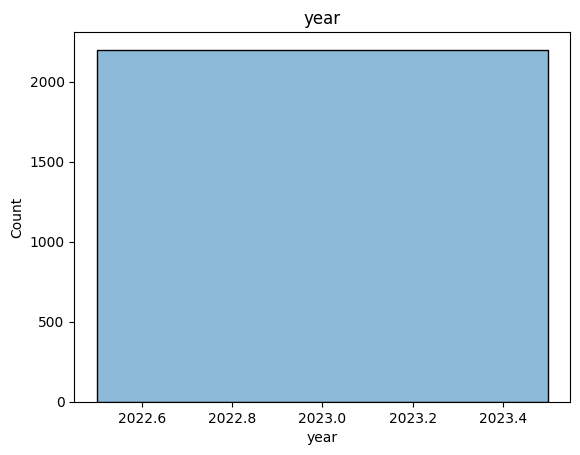

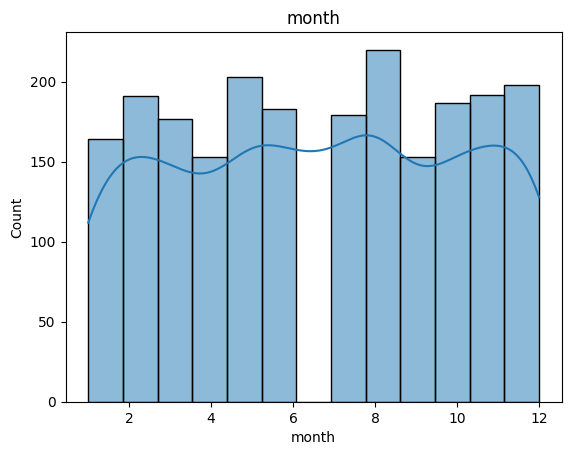

In [14]:
#Distribution plots

for col in df.select_dtypes(include='number').columns:
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

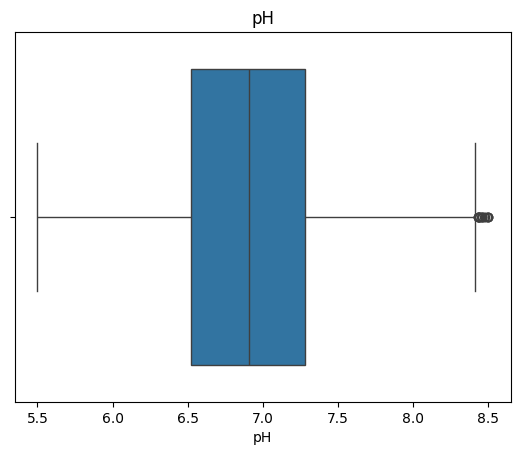

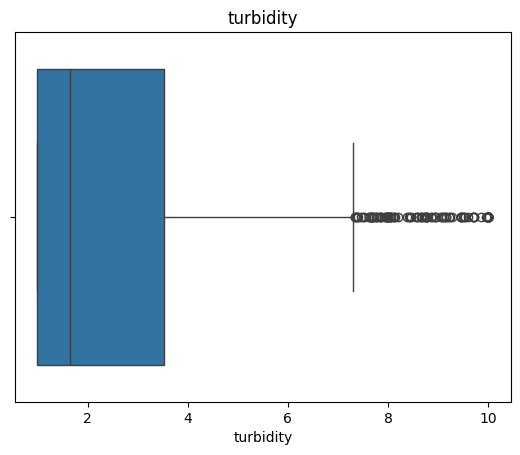

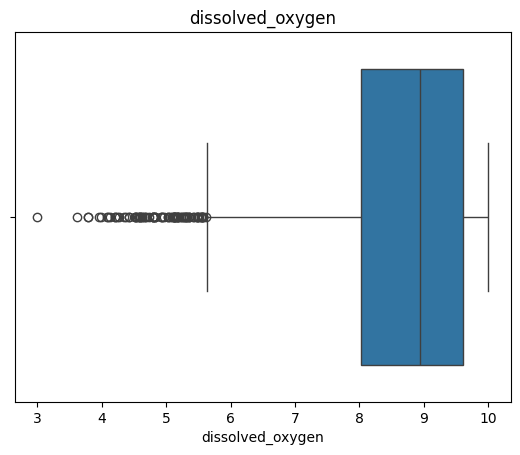

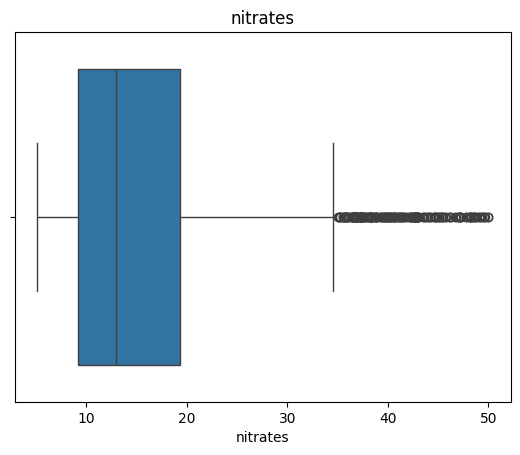

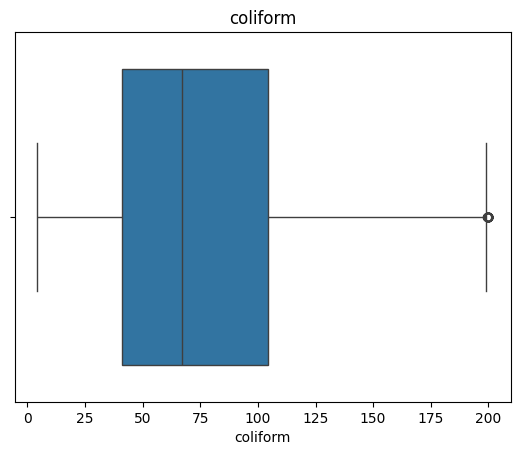

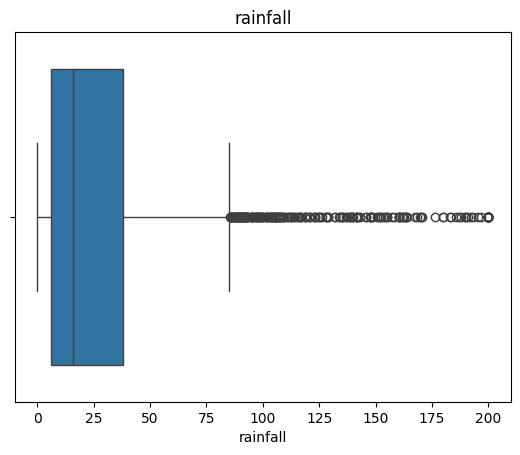

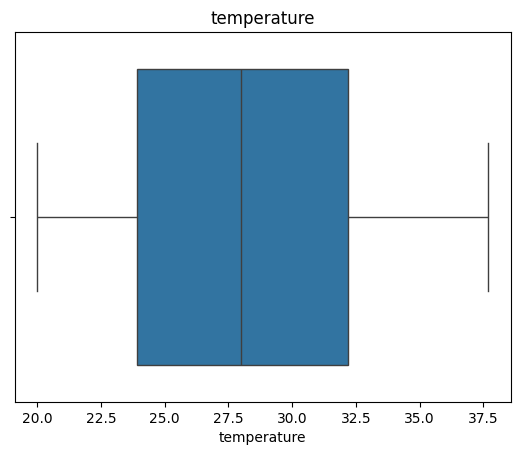

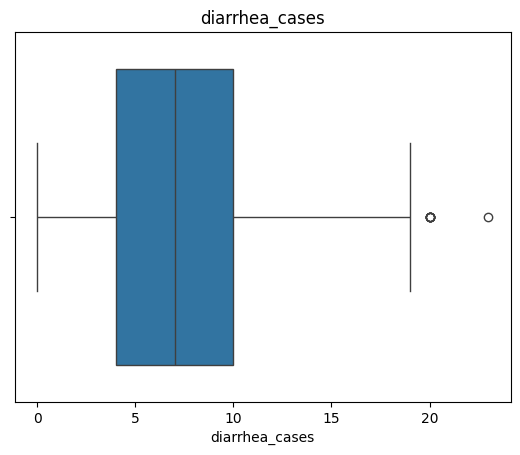

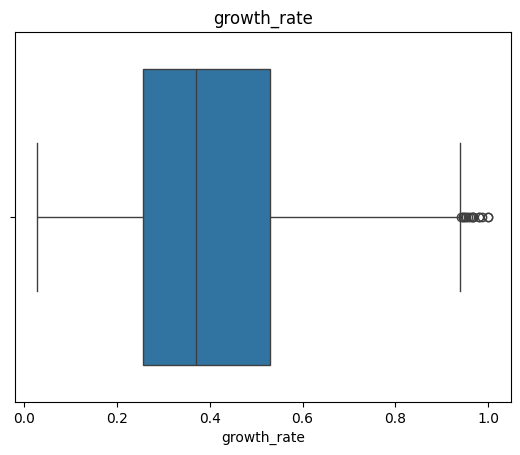

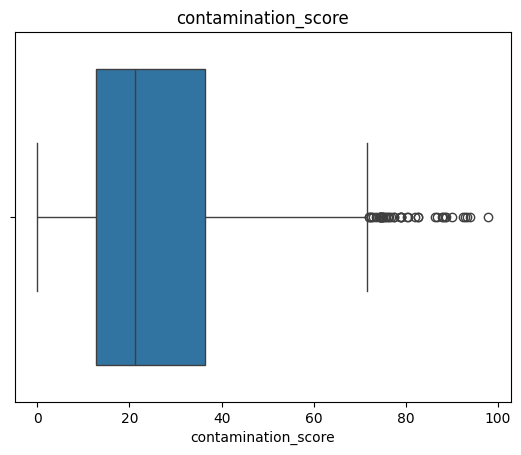

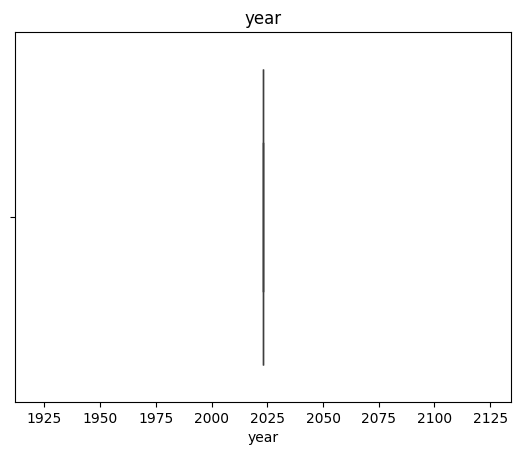

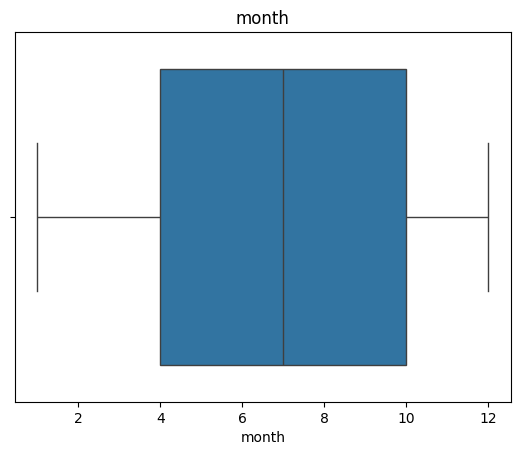

In [16]:
#Boxplots (Outliers detection)
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

BIVARIATE ANALYSIS (Relation with target)

In [17]:
#Correlation with target

corr= df.corr(numeric_only=True)
corr['contamination_score'].sort_values(ascending=False)

,contamination_score
contamination_score,1.000000
coliform,0.898591
growth_rate,0.870015
diarrhea_cases,0.810036
turbidity,0.739025
nitrates,0.569516
rainfall,0.451760
temperature,0.155212
month,0.028243
pH,0.001109


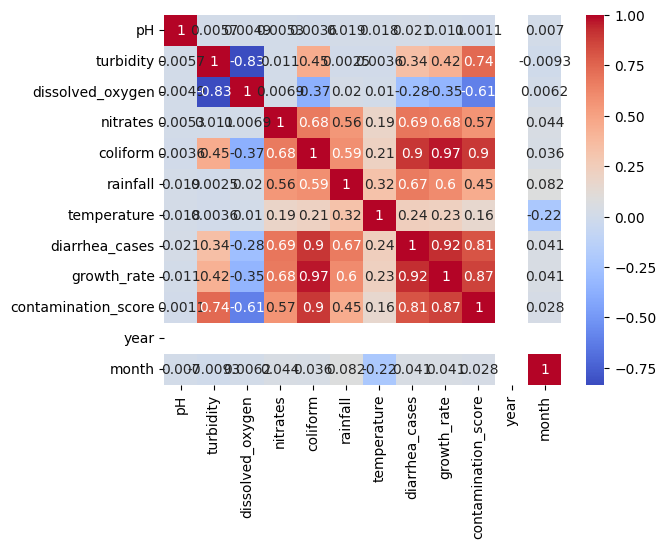

In [18]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

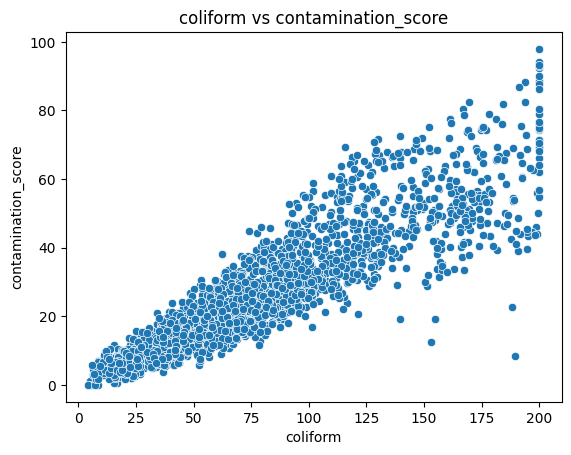

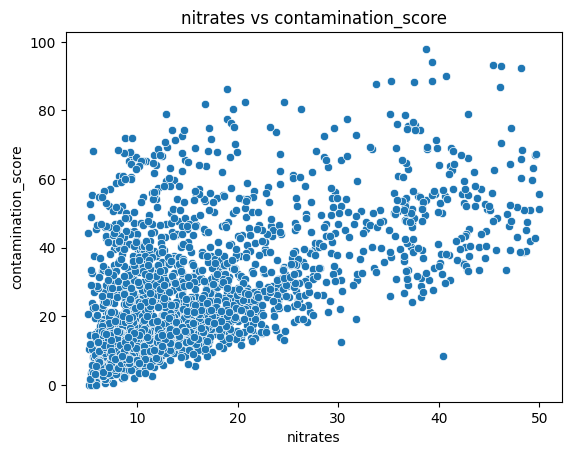

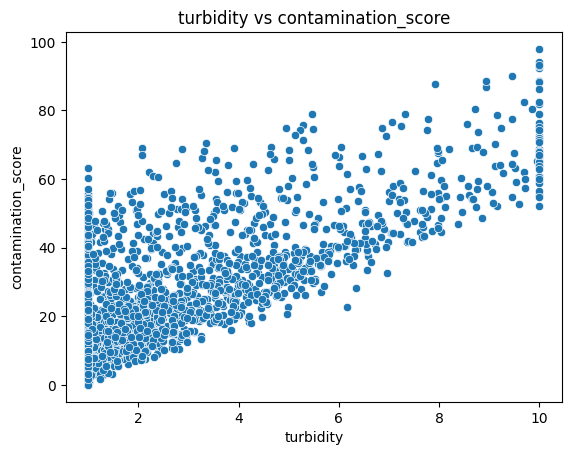

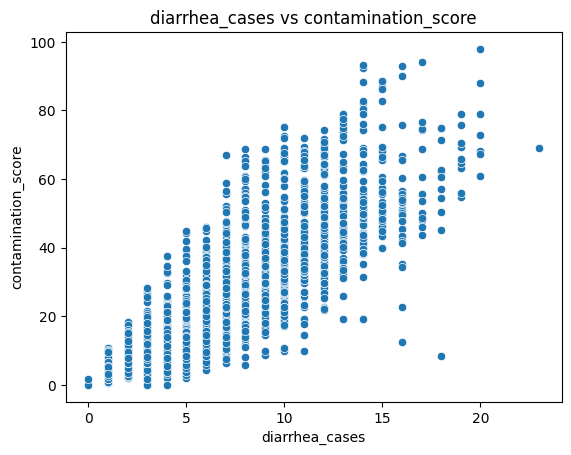

In [19]:
important_features = ['coliform', 'nitrates', 'turbidity', 'diarrhea_cases']

for col in important_features:
    sns.scatterplot(x=df[col], y=df['contamination_score'])
    plt.title(f"{col} vs contamination_score")
    plt.show()

MULTIVARIATE ANALYSIS

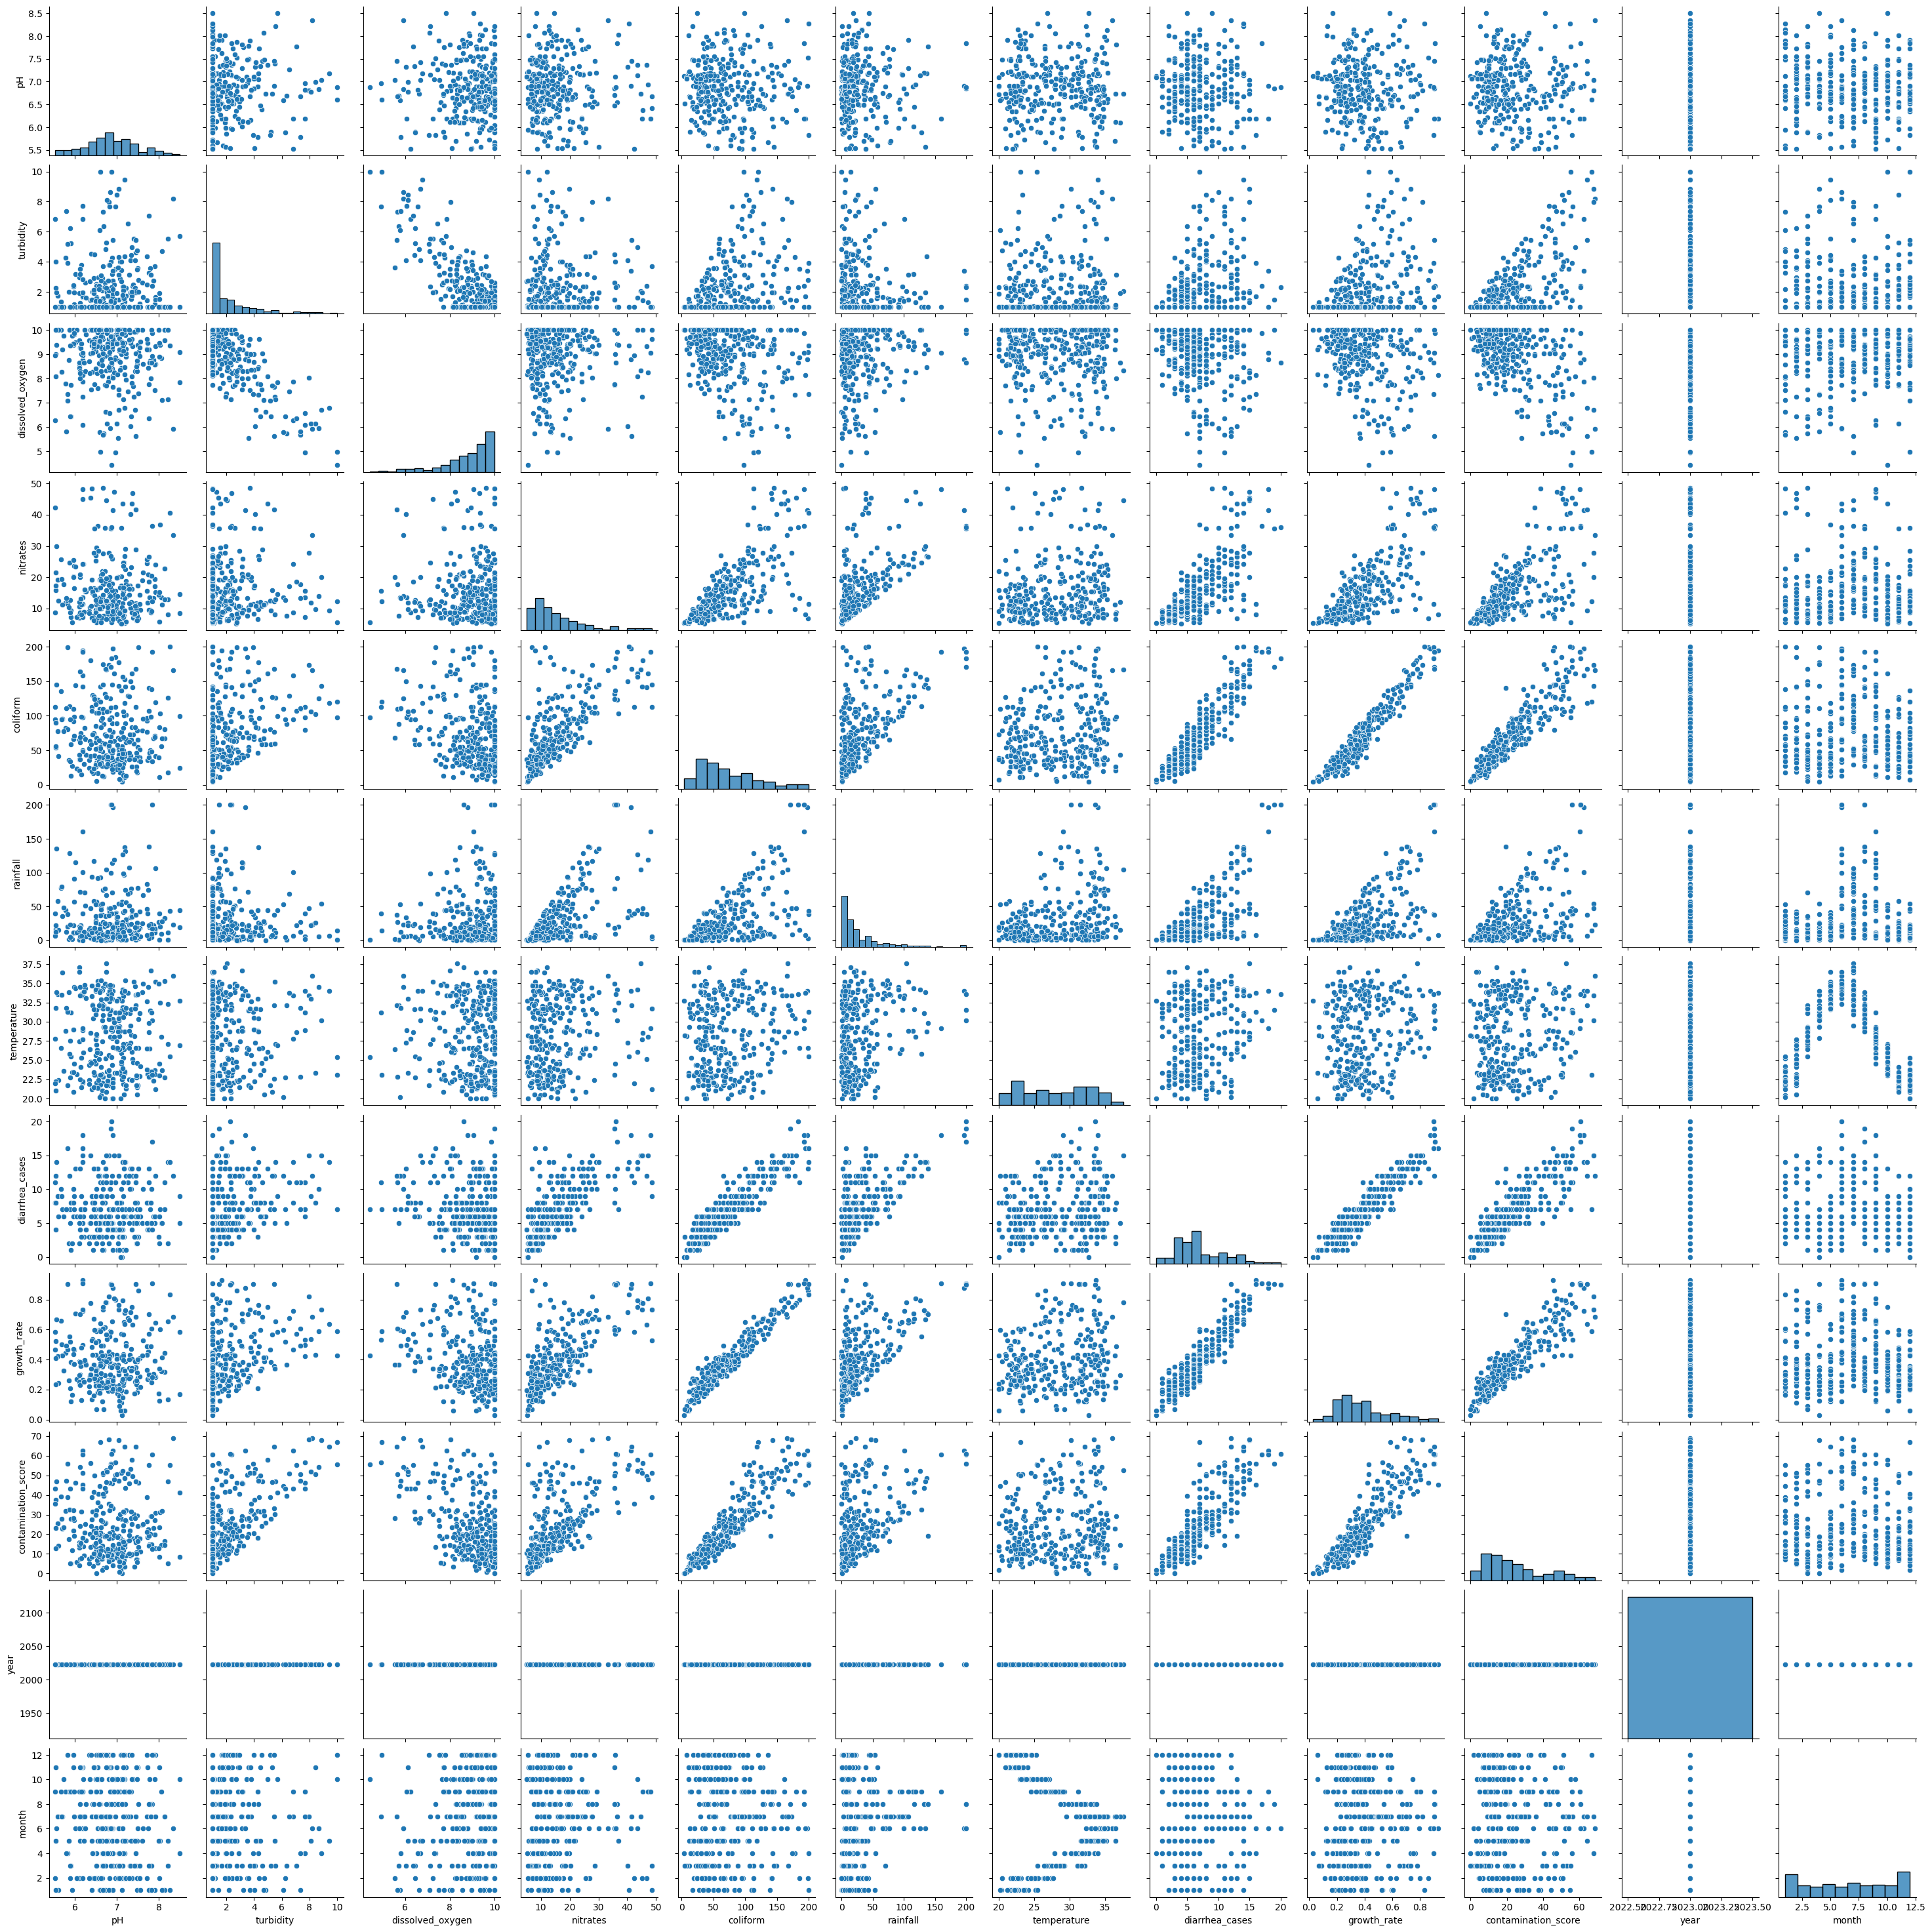

In [20]:
# Pairplot
sns.pairplot(df.sample(300))

In [22]:
#Grouped Analysis (Village-wise)
df.groupby('village')['contamination_score'].mean().sort_values()

,contamination_score
village,
Jawahar Nagar,21.553333
Shivgarh,23.310000
Balkishan,23.404857
Wagholi,23.440000
Sitapur,23.934231
Gopalnagar,23.999583
Dhamangaon,24.641639
Bhavanipur,24.674364
Ranjangaon,25.059452


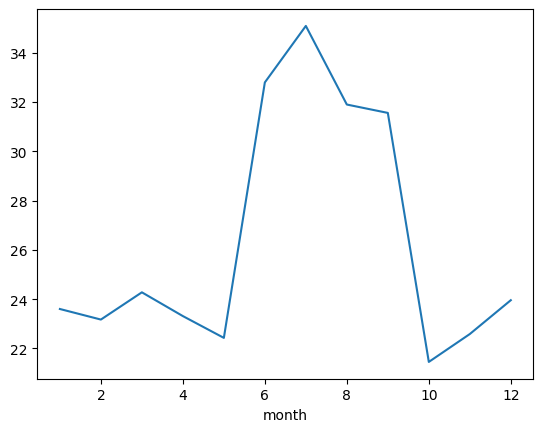

In [23]:
#Monthly Trend
df.groupby('month')['contamination_score'].mean().plot()
plt.show()

TIME SERIES ANALYSIS

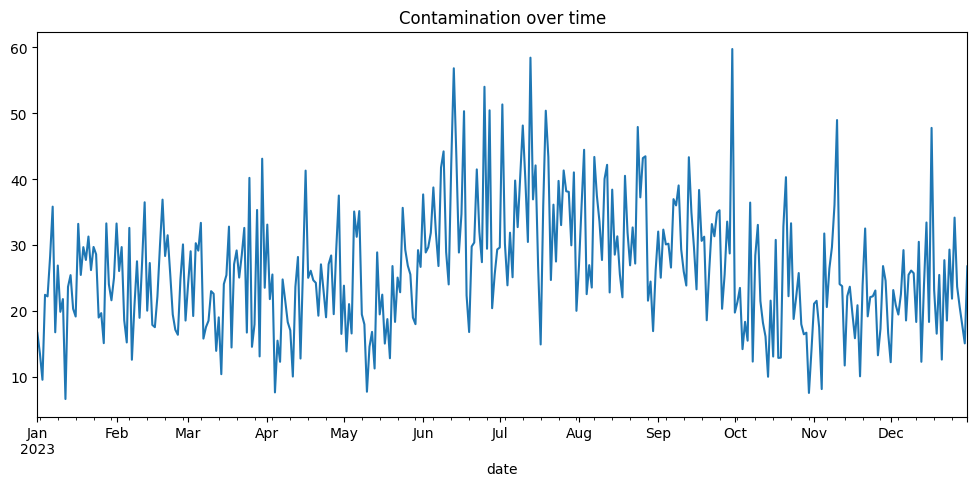

In [25]:
#Trend over time
df.sort_values('date', inplace=True)

df.groupby('date')['contamination_score'].mean().plot(figsize=(12,5))
plt.title("Contamination over time")
plt.show()

In [26]:
#Rolling Mean
df['rolling_mean'] = df['contamination_score'].rolling(7).mean()

FEATURE ENGINEERING

In [27]:
#Interaction Features
df['rainfall_coliform'] = df['rainfall'] * df['coliform']
df['temp_oxygen'] = df['temperature'] * df['dissolved_oxygen']

In [29]:
#Lag Features (Time effect)
df['lag_1'] = df['contamination_score'].shift(1)

In [30]:
#Categorization
df['risk_level'] = pd.cut(df['contamination_score'],
                         bins=[0,10,20,30,100],
                         labels=['Low','Medium','High','Critical'])

OUTLIER DETECTION

In [35]:
# Select only numeric columns
df_numeric = df.select_dtypes(include=['number'])

# IQR Method
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR)))

print(outliers)

         pH  turbidity  dissolved_oxygen  nitrates  coliform  rainfall  \
0     False      False             False     False     False     False   
1     False      False             False     False     False     False   
2     False      False             False     False     False     False   
3     False      False             False     False     False     False   
4     False      False             False     False     False     False   
...     ...        ...               ...       ...       ...       ...   
2194  False      False             False     False     False     False   
2197  False      False             False     False     False     False   
2198  False      False             False     False     False     False   
2196  False      False             False     False     False     False   
2199  False       True              True     False     False     False   

      temperature  diarrhea_cases  growth_rate  contamination_score   year  \
0           False           False

DATA DISTRIBUTION CHECK

In [36]:
#Skewness
df.skew(numeric_only=True)

,0
pH,0.100536
turbidity,1.656056
dissolved_oxygen,-1.230944
nitrates,1.499279
coliform,0.820461
rainfall,2.292646
temperature,0.009426
diarrhea_cases,0.798602
growth_rate,0.755039
contamination_score,1.054702


In [37]:
#Log Transform
df['coliform_log'] = np.log1p(df['coliform'])

FEATURE IMPORTANCE ANALYSIS

<Axes: >

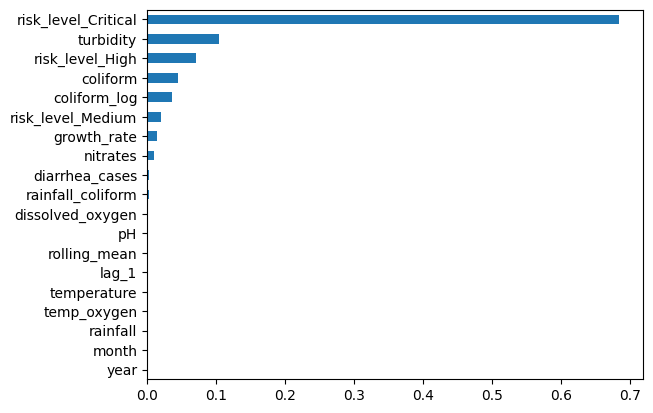

In [39]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Features & target
X = df.drop(['contamination_score', 'date', 'village'], axis=1)
y = df['contamination_score']

# Separate numeric & categorical columns
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# Fill numeric NaNs
X[num_cols] = X[num_cols].fillna(0)

# Fill categorical NaNs (use mode or 'Unknown')
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Convert categorical → numeric (VERY IMPORTANT)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')

HYPOTHESIS TESTING

In [40]:
from scipy.stats import pearsonr

pearsonr(df['rainfall'], df['contamination_score'])

PearsonRResult(statistic=np.float64(0.4517604367081706), pvalue=np.float64(4.228628341468833e-111))

HEALTH IMPACT ANALYSIS

<Axes: xlabel='contamination_score', ylabel='diarrhea_cases'>

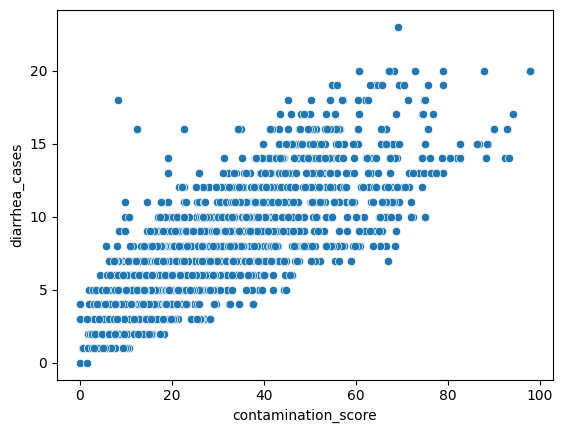

In [41]:
sns.scatterplot(x=df['contamination_score'], y=df['diarrhea_cases'])